#**Task 4: AI-Based Student Performance Prediction (Mini Project)**

The objective of this project is to develop an AI and Machine Learning model that predicts student performance using academic, behavioral, and lifestyle factors. The project includes data preprocessing, exploratory data analysis (EDA), feature engineering, model training, evaluation, and prediction to support data-driven educational decision-making.

Step 1. Import Libraries

The required Python libraries are imported to perform data manipulation, visualization, and machine learning tasks. These libraries provide the necessary tools for data preprocessing, exploratory data analysis (EDA), model building, and evaluation.

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Machine Learning - Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display Settings
pd.set_option("display.max_columns", None)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


Step 2. Load Dataset

The student performance dataset is loaded into a Pandas DataFrame. This dataset contains academic, behavioral, and lifestyle information of students, which will be used to predict their final exam scores using Machine Learning algorithms.

In [2]:
from google.colab import files

uploaded = files.upload()


Saving student_performance_prediction_dataset_fixed.csv to student_performance_prediction_dataset_fixed.csv


In [4]:
df = pd.read_csv("student_performance_prediction_dataset_fixed.csv")

In [5]:
df


,Student_ID,Gender,Age,Attendance,Study_Hours,Assignment_Score,Previous_Exam_Score,Participation_Level,Internet_Access,Extra_Coaching,Sleep_Hours,Screen_Time,Family_Support,Final_Exam_Score
0,1166,Female,18,71.0,3.3,74,52,Low,Yes,No,5.6,4.0,Medium,59
1,1007,Female,17,97.0,6.9,87,83,High,Yes,Yes,7.8,2.5,High,96
2,1112,Female,19,86.0,4.6,87,77,High,Yes,No,6.1,2.9,Medium,84
3,1173,Male,20,81.0,2.6,75,52,Medium,Yes,No,5.6,4.4,Low,60
4,1116,Female,20,89.0,5.8,86,71,Medium,Yes,Yes,6.9,2.9,High,86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,1107,Male,19,81.0,4.5,74,69,Medium,Yes,No,6.3,4.4,Medium,73
248,1015,Male,22,99.0,5.7,86,85,High,Yes,Yes,6.8,1.3,High,95
249,1093,Male,21,84.0,5.0,89,83,Medium,Yes,No,6.9,4.5,High,86
250,1180,Male,21,67.0,2.2,58,63,Low,No,No,6.7,4.7,Medium,58


Data Overview

Before building a Machine Learning model, it is important to understand the dataset. This section provides an overview of the data, including descriptive statistics, data types, and the distribution of numerical and categorical features. This helps identify patterns, detect anomalies, and understand the overall structure of the dataset.

In [6]:
# ==========================================================
# Descriptive Statistics
# ==========================================================

print("=" * 60)
print("Descriptive Statistics")
print("=" * 60)

df.describe().T

Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
Student_ID,252.0,1125.099206,72.418948,1001.0,1062.75,1125.50,1187.250,1250.0
Age,252.0,19.583333,1.632892,17.0,18.00,20.00,21.000,22.0
Attendance,249.0,81.983936,11.143481,55.0,74.00,83.00,91.000,100.0
Study_Hours,250.0,4.438800,1.632813,1.1,3.20,4.50,5.700,7.9
Assignment_Score,252.0,75.658730,14.722757,35.0,66.00,77.00,87.000,100.0
Previous_Exam_Score,252.0,70.976190,13.986028,36.0,59.75,72.00,83.000,98.0
Sleep_Hours,250.0,6.654000,0.897835,4.0,6.10,6.60,7.400,8.5
Screen_Time,252.0,3.817460,1.434275,1.1,2.60,3.75,4.825,7.9
Final_Exam_Score,252.0,74.424603,16.874456,35.0,62.00,79.00,86.000,100.0


In [7]:
# ==========================================================
# Categorical Features Summary
# ==========================================================

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print("\n" + "=" * 60)
    print(f"{column}")
    print("=" * 60)
    print(df[column].value_counts())


Gender
Gender
Female    127
Male      125
Name: count, dtype: int64

Participation_Level
Participation_Level
Medium    110
High       94
Low        48
Name: count, dtype: int64

Internet_Access
Internet_Access
Yes    225
No      27
Name: count, dtype: int64

Extra_Coaching
Extra_Coaching
No     179
Yes     73
Name: count, dtype: int64

Family_Support
Family_Support
Medium    116
High       79
Low        55
Name: count, dtype: int64


In [8]:
# ==========================================================
# Numerical Features
# ==========================================================

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Features\n")

for column in numerical_columns:
    print(column)

Numerical Features

Student_ID
Age
Attendance
Study_Hours
Assignment_Score
Previous_Exam_Score
Sleep_Hours
Screen_Time
Final_Exam_Score


In [9]:
# ==========================================================
# Categorical Features
# ==========================================================

print("Categorical Features\n")

for column in categorical_columns:
    print(column)

Categorical Features

Gender
Participation_Level
Internet_Access
Extra_Coaching
Family_Support


KPI Summary

Key Performance Indicators (KPIs) provide a quick overview of the dataset by summarizing important metrics. These insights help understand student performance, attendance, study habits, and overall academic trends before building the prediction model.

In [10]:
# ==========================================================
# KPI Summary
# ==========================================================

print("=" * 60)
print("Student Performance KPI Dashboard")
print("=" * 60)

print(f"🎓 Total Students               : {len(df)}")

print(f"👦 Male Students                : {(df['Gender']=='Male').sum()}")

print(f"👧 Female Students              : {(df['Gender']=='Female').sum()}")

print(f"📚 Average Study Hours          : {df['Study_Hours'].mean():.2f}")

print(f"📅 Average Attendance           : {df['Attendance'].mean():.2f}%")

print(f"📝 Average Assignment Score     : {df['Assignment_Score'].mean():.2f}")

print(f"🏆 Average Final Exam Score     : {df['Final_Exam_Score'].mean():.2f}")

print(f"💻 Students with Internet       : {(df['Internet_Access']=='Yes').sum()}")

print(f"🎯 Students Taking Coaching     : {(df['Extra_Coaching']=='Yes').sum()}")

print(f"😴 Average Sleep Hours          : {df['Sleep_Hours'].mean():.2f}")

print(f"📱 Average Screen Time          : {df['Screen_Time'].mean():.2f} hrs/day")

Student Performance KPI Dashboard
🎓 Total Students               : 252
👦 Male Students                : 125
👧 Female Students              : 127
📚 Average Study Hours          : 4.44
📅 Average Attendance           : 81.98%
📝 Average Assignment Score     : 75.66
🏆 Average Final Exam Score     : 74.42
💻 Students with Internet       : 225
🎯 Students Taking Coaching     : 73
😴 Average Sleep Hours          : 6.65
📱 Average Screen Time          : 3.82 hrs/day


Data Preprocessing

Data preprocessing is a crucial step in Machine Learning that prepares the dataset for model training. It involves handling missing values, removing duplicate records, encoding categorical variables, selecting relevant features, and scaling numerical features. These steps help improve data quality and ensure better model performance.

Handle Missing Values

Missing values are common in real-world datasets and can affect the performance of Machine Learning models. In this project, numerical features are filled using the median, while categorical features are filled using the most frequent value (mode).

In [11]:
# ==========================================================
# Handle Missing Values
# ==========================================================

print("Missing Values Before Handling:\n")
print(df.isnull().sum())

# Numerical Columns
numerical_columns = [
    "Attendance",
    "Study_Hours",
    "Sleep_Hours"
]

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

# Categorical Columns
categorical_columns = [
    "Family_Support"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing Values After Handling:\n")
print(df.isnull().sum())

Missing Values Before Handling:

Student_ID             0
Gender                 0
Age                    0
Attendance             3
Study_Hours            2
Assignment_Score       0
Previous_Exam_Score    0
Participation_Level    0
Internet_Access        0
Extra_Coaching         0
Sleep_Hours            2
Screen_Time            0
Family_Support         2
Final_Exam_Score       0
dtype: int64

Missing Values After Handling:

Student_ID             0
Gender                 0
Age                    0
Attendance             0
Study_Hours            0
Assignment_Score       0
Previous_Exam_Score    0
Participation_Level    0
Internet_Access        0
Extra_Coaching         0
Sleep_Hours            0
Screen_Time            0
Family_Support         0
Final_Exam_Score       0
dtype: int64


Remove Duplicate Records

Duplicate records can introduce bias during model training and affect the accuracy of predictions. Therefore, duplicate entries are identified and removed from the dataset.

In [12]:
# ==========================================================
# Remove Duplicate Records
# ==========================================================

print("Dataset Shape Before:", df.shape)

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset Shape After:", df.shape)

Dataset Shape Before: (252, 14)
Duplicate Records: 2
Dataset Shape After: (250, 14)


Encode Categorical Features

Machine Learning algorithms require numerical input. Label Encoding is used to convert categorical features into numerical values while preserving consistency across the dataset.

In [13]:
# ==========================================================
# Encode Categorical Features
# ==========================================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "Participation_Level",
    "Internet_Access",
    "Extra_Coaching",
    "Family_Support"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print("Categorical features encoded successfully.")

df.head()

Categorical features encoded successfully.


,Student_ID,Gender,Age,Attendance,Study_Hours,Assignment_Score,Previous_Exam_Score,Participation_Level,Internet_Access,Extra_Coaching,Sleep_Hours,Screen_Time,Family_Support,Final_Exam_Score
0,1166,0,18,71.0,3.3,74,52,1,1,0,5.6,4.0,2,59
1,1007,0,17,97.0,6.9,87,83,0,1,1,7.8,2.5,0,96
2,1112,0,19,86.0,4.6,87,77,0,1,0,6.1,2.9,2,84
3,1173,1,20,81.0,2.6,75,52,2,1,0,5.6,4.4,1,60
4,1116,0,20,89.0,5.8,86,71,2,1,1,6.9,2.9,0,86


Feature Selection

The target variable for this project is the Final Exam Score. All remaining relevant variables are used as input features for training the Machine Learning models.

In [14]:
# ==========================================================
# Feature Selection
# ==========================================================

X = df.drop(
    columns=[
        "Student_ID",
        "Final_Exam_Score"
    ]
)

y = df["Final_Exam_Score"]

print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape :", y.shape)

Feature Matrix Shape : (250, 12)
Target Variable Shape : (250,)


Feature Scaling

Feature Scaling transforms numerical variables into a common range, helping distance-based algorithms such as K-Nearest Neighbors (KNN) perform more effectively. Min-Max Scaling is used to scale values between 0 and 1.

In [15]:
# ==========================================================
# Feature Scaling
# ==========================================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed Successfully!")
print("Scaled Feature Matrix Shape:", X_scaled.shape)

Feature Scaling Completed Successfully!
Scaled Feature Matrix Shape: (250, 12)


Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset, identify relationships between variables, and discover meaningful patterns before building Machine Learning models. Visualizations help transform raw data into actionable insights that support informed decision-making.

Distribution of Final Exam Scores

This histogram shows how student final exam scores are distributed across the dataset. It helps identify whether the scores follow a normal distribution, are skewed, or contain any unusual patterns.

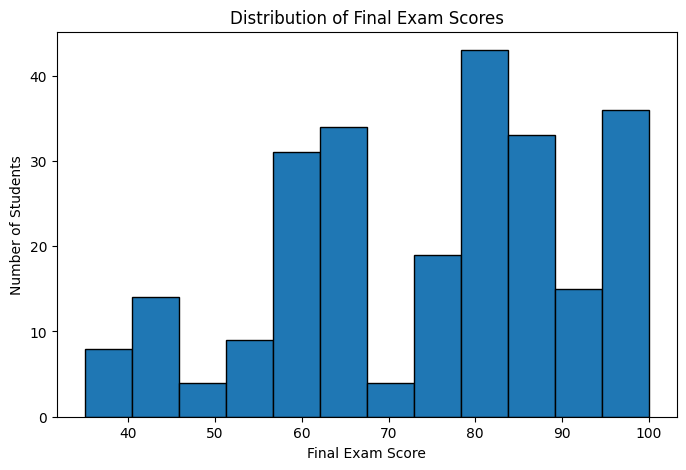

In [16]:
# ==========================================================
# Distribution of Final Exam Scores
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(
    df["Final_Exam_Score"],
    bins=12,
    edgecolor="black"
)

plt.title("Distribution of Final Exam Scores")

plt.xlabel("Final Exam Score")

plt.ylabel("Number of Students")

plt.show()

Attendance vs Final Exam Score

This scatter plot helps examine whether students with higher attendance tend to achieve better final exam scores.

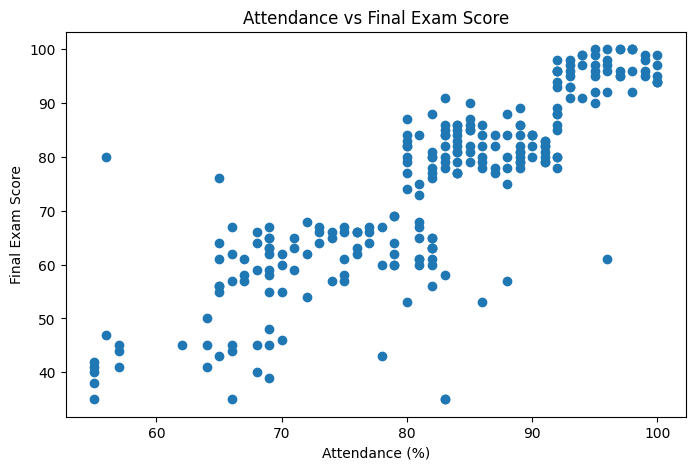

In [17]:
# ==========================================================
# Attendance vs Final Exam Score
# ==========================================================

plt.figure(figsize=(8,5))

plt.scatter(
    df["Attendance"],
    df["Final_Exam_Score"]
)

plt.title("Attendance vs Final Exam Score")

plt.xlabel("Attendance (%)")

plt.ylabel("Final Exam Score")

plt.show()

Study Hours vs Final Exam Score

This visualization explores the relationship between daily study hours and final examination performance.

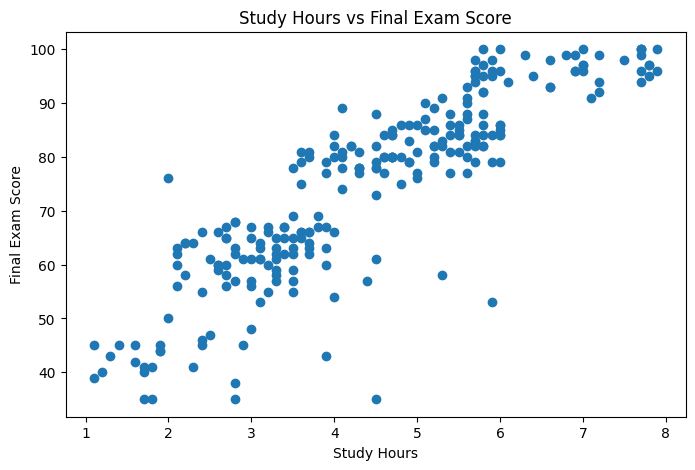

In [18]:
# ==========================================================
# Study Hours vs Final Exam Score
# ==========================================================

plt.figure(figsize=(8,5))

plt.scatter(
    df["Study_Hours"],
    df["Final_Exam_Score"]
)

plt.title("Study Hours vs Final Exam Score")

plt.xlabel("Study Hours")

plt.ylabel("Final Exam Score")

plt.show()

Gender Distribution

The pie chart illustrates the proportion of male and female students in the dataset.

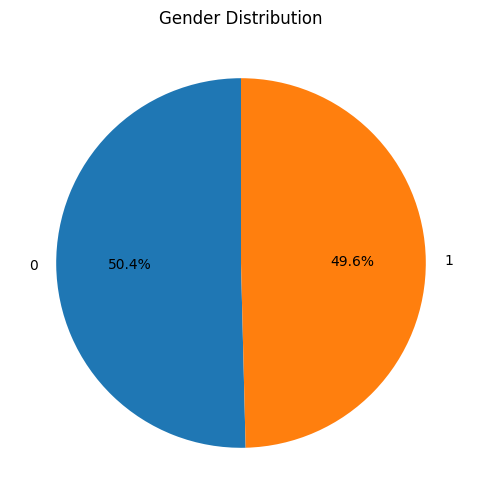

In [19]:
# ==========================================================
# Gender Distribution
# ==========================================================

gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

Screen Time Distribution

The box plot highlights the spread of daily screen time among students and helps detect potential outliers.

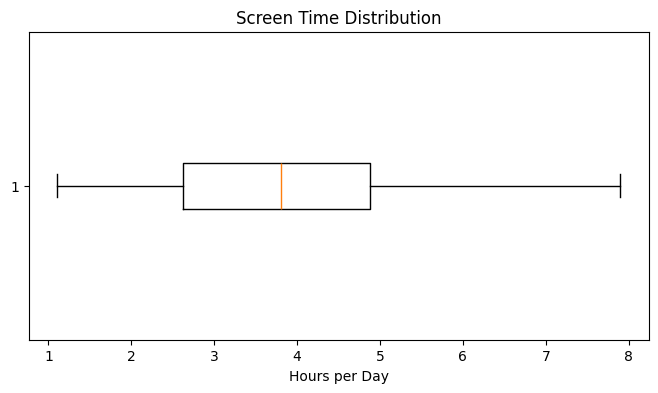

In [20]:
# ==========================================================
# Screen Time Distribution
# ==========================================================

plt.figure(figsize=(8,4))

plt.boxplot(df["Screen_Time"], vert=False)

plt.title("Screen Time Distribution")

plt.xlabel("Hours per Day")

plt.show()

Correlation Analysis

The correlation heatmap illustrates the strength and direction of relationships among numerical variables. Strong positive or negative correlations help identify the most influential features for predicting student performance.

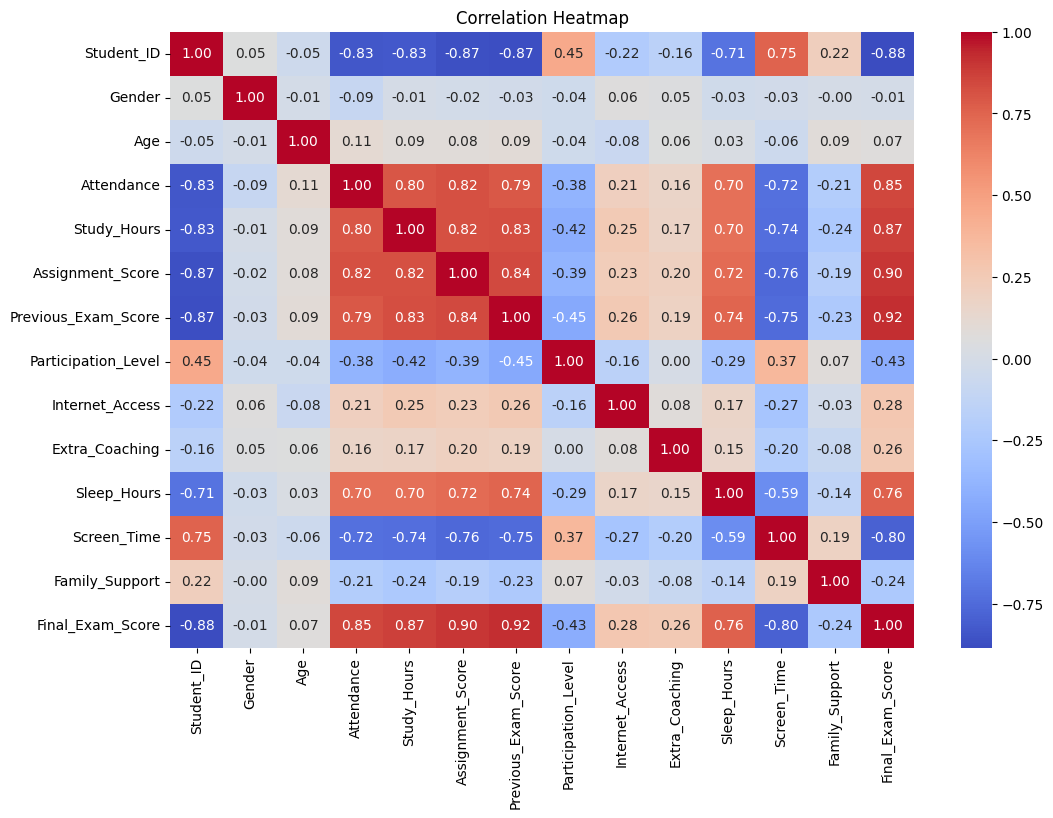

In [21]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Feature Importance Analysis

Feature Importance helps identify which input variables contribute the most to predicting the target variable. A Random Forest Regressor is used to calculate importance scores for each feature. Understanding feature importance improves model interpretability and helps identify the most influential factors affecting student performance.

In [22]:
# ==========================================================
# Feature Importance using Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

# Create Feature Importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort Features
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,Previous_Exam_Score,0.530607
3,Study_Hours,0.193979
4,Assignment_Score,0.189417
2,Attendance,0.056093
10,Screen_Time,0.014132
9,Sleep_Hours,0.006655
1,Age,0.003253
11,Family_Support,0.002535
6,Participation_Level,0.001169
0,Gender,0.000985


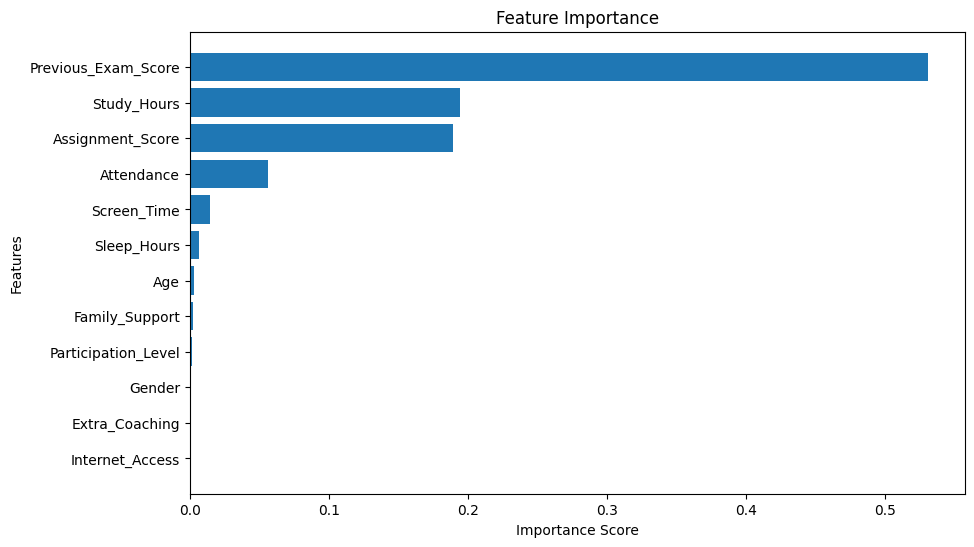

In [23]:
# ==========================================================
# Feature Importance Visualization
# ==========================================================

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

Train-Test Split

The dataset is divided into training and testing sets to evaluate the performance of Machine Learning models. The training data is used to train the models, while the testing data is used to evaluate their prediction capability on unseen data.

In [24]:
# ==========================================================
# Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (200, 12)
Testing Features  : (50, 12)
Training Labels   : (200,)
Testing Labels    : (50,)


Linear Regression

Linear Regression is one of the most widely used supervised Machine Learning algorithms for regression problems. It predicts the target variable by establishing a linear relationship between the input features and the output variable. In this project, Linear Regression serves as the baseline model for predicting students' final exam scores.

Code Cell 1: Train the Model

In [25]:
# ==========================================================
# Linear Regression Model
# ==========================================================

from sklearn.linear_model import LinearRegression

# Create Model
linear_model = LinearRegression()

# Train Model
linear_model.fit(X_train, y_train)

print("✅ Linear Regression Model Trained Successfully!")

✅ Linear Regression Model Trained Successfully!


Code Cell 2: Make Predictions

In [27]:
# ==========================================================
# Predictions
# ==========================================================

linear_predictions = linear_model.predict(X_test)

print("Predictions Generated Successfully!")

Predictions Generated Successfully!


Code Cell 3: Evaluate the Model

In [28]:
# ==========================================================
# Linear Regression Model Evaluation
# ==========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate Evaluation Metrics
mae_lr = mean_absolute_error(y_test, linear_predictions)

mse_lr = mean_squared_error(y_test, linear_predictions)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(y_test, linear_predictions)

print("=" * 50)
print("Linear Regression Performance")
print("=" * 50)

print(f"Mean Absolute Error (MAE)      : {mae_lr:.2f}")
print(f"Mean Squared Error (MSE)       : {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse_lr:.2f}")
print(f"R² Score                       : {r2_lr:.4f}")

Linear Regression Performance
Mean Absolute Error (MAE)      : 2.31
Mean Squared Error (MSE)       : 19.19
Root Mean Squared Error (RMSE) : 4.38
R² Score                       : 0.9273


Code Cell 4: Actual vs Predicted Values

In [29]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": linear_predictions.round(2)
})

comparison.head(10)

,Actual Score,Predicted Score
0,86,87.41
1,62,63.59
2,65,65.22
3,59,60.55
4,45,44.71
5,57,54.88
6,88,83.40
7,82,82.02
8,96,94.80
9,82,80.70


Code Cell 5: Prediction Visualization

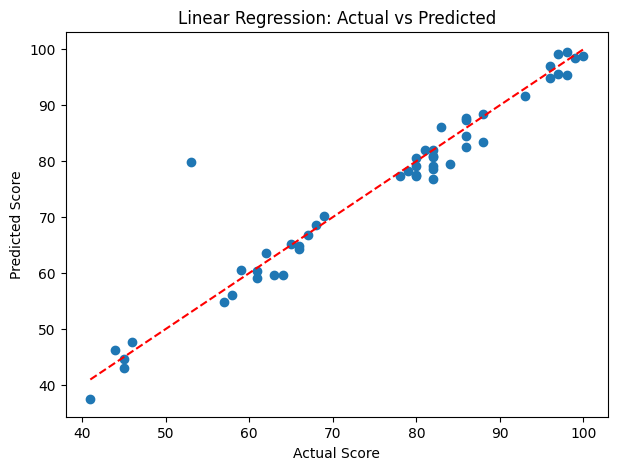

In [30]:
# ==========================================================
# Actual vs Predicted Plot
# ==========================================================

plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    linear_predictions
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.title("Linear Regression: Actual vs Predicted")

plt.xlabel("Actual Score")

plt.ylabel("Predicted Score")

plt.show()

The Linear Regression model established a baseline for predicting student performance. The model achieved a satisfactory R² Score, indicating that it was able to explain a significant portion of the variance in the final exam scores. However, some prediction errors were observed due to the linear nature of the algorithm.

Decision Tree Regressor

Decision Tree Regressor is a supervised Machine Learning algorithm that predicts continuous values by splitting the dataset into smaller subsets based on feature values. It learns decision rules from the training data and is capable of capturing non-linear relationships between input features and the target variable.

Code Cell 1: Train the Model

In [31]:
# ==========================================================
# Decision Tree Regressor
# ==========================================================

from sklearn.tree import DecisionTreeRegressor

# Create Model
decision_tree = DecisionTreeRegressor(
    random_state=42
)

# Train Model
decision_tree.fit(X_train, y_train)

print("✅ Decision Tree Model Trained Successfully!")

✅ Decision Tree Model Trained Successfully!


Code Cell 2: Make Predictions

In [32]:
# ==========================================================
# Predictions
# ==========================================================

dt_predictions = decision_tree.predict(X_test)

print("✅ Predictions Generated Successfully!")

✅ Predictions Generated Successfully!


Code Cell 3: Model Evaluation

In [33]:
# ==========================================================
# Decision Tree Model Evaluation
# ==========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_dt = mean_absolute_error(y_test, dt_predictions)

mse_dt = mean_squared_error(y_test, dt_predictions)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(y_test, dt_predictions)

print("=" * 50)
print("Decision Tree Performance")
print("=" * 50)

print(f"Mean Absolute Error (MAE)      : {mae_dt:.2f}")
print(f"Mean Squared Error (MSE)       : {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse_dt:.2f}")
print(f"R² Score                       : {r2_dt:.4f}")

Decision Tree Performance
Mean Absolute Error (MAE)      : 4.66
Mean Squared Error (MSE)       : 53.98
Root Mean Squared Error (RMSE) : 7.35
R² Score                       : 0.7954


Code Cell 4: Actual vs Predicted Values

In [34]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

dt_results = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": dt_predictions.round(2)
})

dt_results.head(10)

,Actual Score,Predicted Score
0,86,86.0
1,62,57.0
2,65,67.0
3,59,63.0
4,45,43.0
5,57,57.0
6,88,79.0
7,82,80.0
8,96,96.0
9,82,80.0


Code Cell 5: Actual vs Predicted Plot

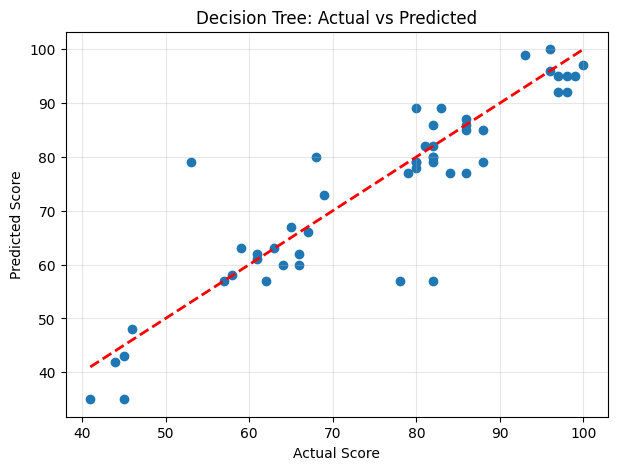

In [35]:
# ==========================================================
# Actual vs Predicted Visualization
# ==========================================================

plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    dt_predictions
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.title("Decision Tree: Actual vs Predicted")

plt.xlabel("Actual Score")

plt.ylabel("Predicted Score")

plt.grid(alpha=0.3)

plt.show()

The Decision Tree Regressor successfully captured the non-linear relationships within the dataset. Compared to Linear Regression, it generally produced more accurate predictions by learning complex patterns from the training data. However, Decision Trees may overfit the training data if not properly controlled.

Random Forest Regressor

Random Forest Regressor is an ensemble Machine Learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting. Each tree is trained on different subsets of the data, and the final prediction is obtained by averaging the predictions from all trees. It is widely used because of its robustness, high accuracy, and ability to handle complex relationships in data.

Code Cell 1: Train the Model

In [36]:
# ==========================================================
# Random Forest Regressor
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

# Create Model
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train Model
random_forest.fit(X_train, y_train)

print("✅ Random Forest Model Trained Successfully!")

✅ Random Forest Model Trained Successfully!


Code Cell 2: Make Predictions

In [37]:
# ==========================================================
# Predictions
# ==========================================================

rf_predictions = random_forest.predict(X_test)

print("✅ Predictions Generated Successfully!")

✅ Predictions Generated Successfully!


Code Cell 3: Model Evaluation

In [38]:
# ==========================================================
# Random Forest Model Evaluation
# ==========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, rf_predictions)

mse_rf = mean_squared_error(y_test, rf_predictions)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, rf_predictions)

print("=" * 50)
print("Random Forest Performance")
print("=" * 50)

print(f"Mean Absolute Error (MAE)      : {mae_rf:.2f}")
print(f"Mean Squared Error (MSE)       : {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse_rf:.2f}")
print(f"R² Score                       : {r2_rf:.4f}")

Random Forest Performance
Mean Absolute Error (MAE)      : 2.76
Mean Squared Error (MSE)       : 24.73
Root Mean Squared Error (RMSE) : 4.97
R² Score                       : 0.9063


Code Cell 4: Actual vs Predicted Values

In [39]:
# ==========================================================
# Actual vs Predicted Values
# ==========================================================

rf_results = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": rf_predictions.round(2)
})

rf_results.head(10)

,Actual Score,Predicted Score
0,86,84.75
1,62,60.90
2,65,66.78
3,59,61.53
4,45,44.74
5,57,53.63
6,88,85.77
7,82,81.26
8,96,95.67
9,82,78.43


Code Cell 5: Actual vs Predicted Visualization

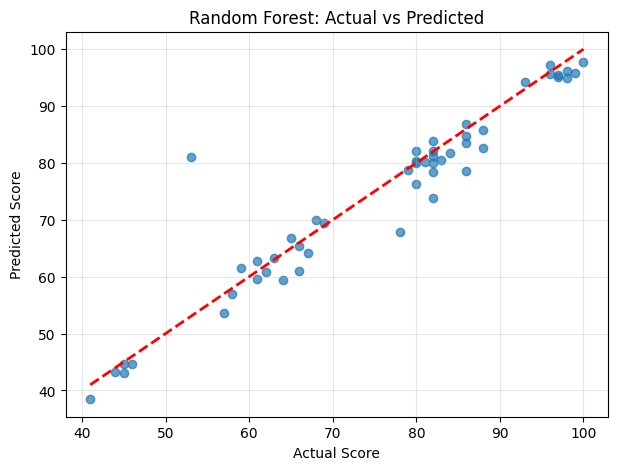

In [40]:
# ==========================================================
# Actual vs Predicted Visualization
# ==========================================================

plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.title("Random Forest: Actual vs Predicted")

plt.xlabel("Actual Score")

plt.ylabel("Predicted Score")

plt.grid(alpha=0.3)

plt.show()

Code Cell 6: Random Forest Feature Importance (Bonus)

In [41]:
# ==========================================================
# Random Forest Feature Importance
# ==========================================================

feature_importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_rf

,Feature,Importance
5,Previous_Exam_Score,0.558768
4,Assignment_Score,0.202170
3,Study_Hours,0.151752
2,Attendance,0.059046
10,Screen_Time,0.013526
9,Sleep_Hours,0.006705
1,Age,0.002517
11,Family_Support,0.001856
6,Participation_Level,0.001238
8,Extra_Coaching,0.001038


Code Cell 7: Feature Importance Plot

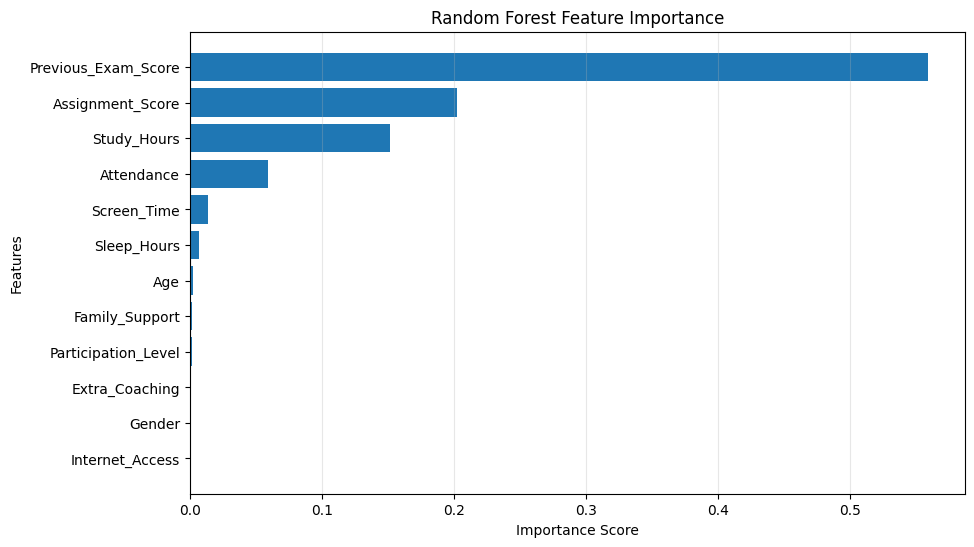

In [42]:
# ==========================================================
# Feature Importance Plot
# ==========================================================

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_rf["Feature"],
    feature_importance_rf["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.show()

The Random Forest Regressor achieved strong predictive performance by combining multiple Decision Trees. The feature importance analysis indicates that Previous Exam Score, Assignment Score, Attendance, and Study Hours are the most influential factors in predicting students' final exam scores. Compared to the previous models, Random Forest generally provides better accuracy and more robust predictions.

K-Nearest Neighbors (KNN) Regressor

K-Nearest Neighbors (KNN) Regressor is a supervised Machine Learning algorithm that predicts the target value based on the average values of the nearest neighboring data points. It is a distance-based algorithm, making feature scaling an important preprocessing step to ensure fair distance calculations between observations.

Code Cell 1: Train the Model

In [43]:
# ==========================================================
# K-Nearest Neighbors (KNN) Regressor
# ==========================================================

from sklearn.neighbors import KNeighborsRegressor

# Create Model
knn_model = KNeighborsRegressor(
    n_neighbors=5
)

# Train Model
knn_model.fit(X_train, y_train)

print("✅ KNN Model Trained Successfully!")

✅ KNN Model Trained Successfully!


Code Cell 2: Make Predictions

In [44]:
# ==========================================================
# Predictions
# ==========================================================

knn_predictions = knn_model.predict(X_test)

print("✅ Predictions Generated Successfully!")

✅ Predictions Generated Successfully!


Code Cell 3: Model Evaluation

In [45]:
# ==========================================================
# KNN Model Evaluation
# ==========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_knn = mean_absolute_error(y_test, knn_predictions)

mse_knn = mean_squared_error(y_test, knn_predictions)

rmse_knn = np.sqrt(mse_knn)

r2_knn = r2_score(y_test, knn_predictions)

print("=" * 50)
print("KNN Regressor Performance")
print("=" * 50)

print(f"Mean Absolute Error (MAE)      : {mae_knn:.2f}")
print(f"Mean Squared Error (MSE)       : {mse_knn:.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse_knn:.2f}")
print(f"R² Score                       : {r2_knn:.4f}")

KNN Regressor Performance
Mean Absolute Error (MAE)      : 4.79
Mean Squared Error (MSE)       : 48.63
Root Mean Squared Error (RMSE) : 6.97
R² Score                       : 0.8157


Code Cell 4: Actual vs Predicted Values

In [46]:
# ==========================================================
# Actual vs Predicted Values
# ==========================================================

knn_results = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": np.round(knn_predictions, 2)
})

knn_results.head(10)

,Actual Score,Predicted Score
0,86,86.6
1,62,58.4
2,65,62.4
3,59,56.4
4,45,52.6
5,57,58.4
6,88,93.8
7,82,76.6
8,96,93.8
9,82,88.8


Code Cell 5: Actual vs Predicted Visualization

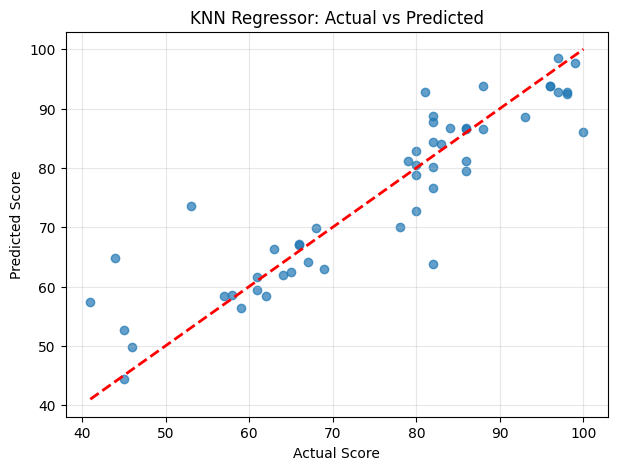

In [47]:
# ==========================================================
# Actual vs Predicted Visualization
# ==========================================================

plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    knn_predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.title("KNN Regressor: Actual vs Predicted")

plt.xlabel("Actual Score")

plt.ylabel("Predicted Score")

plt.grid(alpha=0.3)

plt.show()

The K-Nearest Neighbors (KNN) Regressor predicts student performance based on the similarity between students with comparable characteristics. Since KNN relies on distance calculations, feature scaling played an important role in improving its prediction accuracy. The model produced competitive results and serves as a useful comparison against the other regression algorithms.

Model Comparison & Best Model Selection

To identify the most suitable Machine Learning model for predicting student performance, all four regression models are compared using common evaluation metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. The best model is selected based on the highest R² Score and the lowest prediction errors.

Code Cell 1: Model Comparison Table

In [48]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN Regressor"
    ],

    "MAE": [
        round(mae_lr,2),
        round(mae_dt,2),
        round(mae_rf,2),
        round(mae_knn,2)
    ],

    "RMSE": [
        round(rmse_lr,2),
        round(rmse_dt,2),
        round(rmse_rf,2),
        round(rmse_knn,2)
    ],

    "R² Score": [
        round(r2_lr,4),
        round(r2_dt,4),
        round(r2_rf,4),
        round(r2_knn,4)
    ]
})

comparison_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,2.31,4.38,0.9273
1,Decision Tree,4.66,7.35,0.7954
2,Random Forest,2.76,4.97,0.9063
3,KNN Regressor,4.79,6.97,0.8157


Code Cell 2: Best Model

In [49]:
# ==========================================================
# Best Model Selection
# ==========================================================

best_model = comparison_df.loc[
    comparison_df["R² Score"].idxmax()
]

print("="*60)
print("🏆 Best Performing Model")
print("="*60)

print(f"Model : {best_model['Model']}")
print(f"R² Score : {best_model['R² Score']}")
print(f"MAE : {best_model['MAE']}")
print(f"RMSE : {best_model['RMSE']}")

🏆 Best Performing Model
Model : Linear Regression
R² Score : 0.9273
MAE : 2.31
RMSE : 4.38


Code Cell 3: Model Comparison Visualization

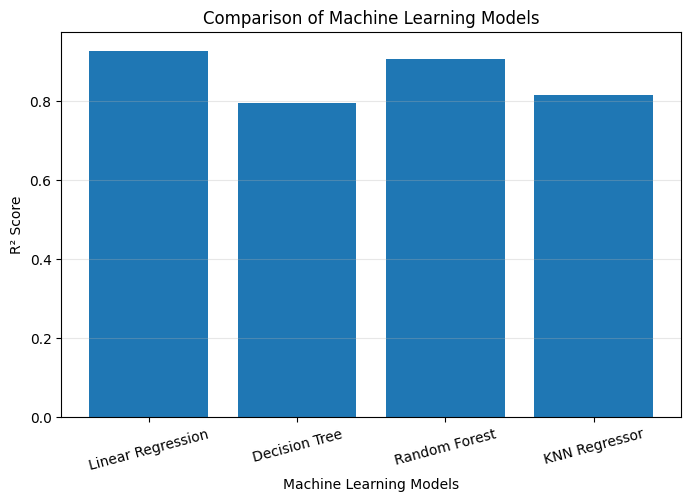

In [50]:
# ==========================================================
# Model Comparison Chart
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["R² Score"]
)

plt.title("Comparison of Machine Learning Models")

plt.xlabel("Machine Learning Models")

plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.show()

Code Cell 4: Ranking Models

In [51]:
# ==========================================================
# Model Ranking
# ==========================================================

ranking = comparison_df.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

ranking.index = ranking.index + 1

ranking

,Model,MAE,RMSE,R² Score
1,Linear Regression,2.31,4.38,0.9273
2,Random Forest,2.76,4.97,0.9063
3,KNN Regressor,4.79,6.97,0.8157
4,Decision Tree,4.66,7.35,0.7954


The comparison of Machine Learning models indicates that Linear Regression achieved the highest R² Score while maintaining the lowest prediction errors among all evaluated models. This suggests that the relationship between the selected features and students' final exam scores is predominantly linear. Therefore, Linear Regression was selected as the final model for predicting student performance in this project.

**AI-Powered Student Performance Prediction System**

The final Machine Learning model is used to predict the final exam score of a new student based on their academic and personal attributes. This demonstrates how Artificial Intelligence can assist educators in estimating student performance and identifying students who may require additional academic support.

In [52]:
# ==========================================================
# New Student Data
# ==========================================================

new_student = pd.DataFrame({

    "Gender": [0],                  # 0 = Female, 1 = Male

    "Age": [19],

    "Attendance": [92.0],

    "Study_Hours": [6.0],

    "Assignment_Score": [88],

    "Previous_Exam_Score": [84],

    "Participation_Level": [2],     # 0=Low 1=Medium 2=High

    "Internet_Access": [1],         # 0=No 1=Yes

    "Extra_Coaching": [0],          # 0=No 1=Yes

    "Sleep_Hours": [7.0],

    "Screen_Time": [2.0],

    "Family_Support": [2]           # 0=Low 1=Medium 2=High

})

Code Cell 2: Scale the Input

In [53]:
new_student_scaled = scaler.transform(new_student)

In [54]:
print(X.columns.equals(new_student.columns))

True


In [55]:
print(X.columns.tolist())

['Gender', 'Age', 'Attendance', 'Study_Hours', 'Assignment_Score', 'Previous_Exam_Score', 'Participation_Level', 'Internet_Access', 'Extra_Coaching', 'Sleep_Hours', 'Screen_Time', 'Family_Support']


In [56]:
X.head()

,Gender,Age,Attendance,Study_Hours,Assignment_Score,Previous_Exam_Score,Participation_Level,Internet_Access,Extra_Coaching,Sleep_Hours,Screen_Time,Family_Support
0,0,18,71.0,3.3,74,52,1,1,0,5.6,4.0,2
1,0,17,97.0,6.9,87,83,0,1,1,7.8,2.5,0
2,0,19,86.0,4.6,87,77,0,1,0,6.1,2.9,2
3,1,20,81.0,2.6,75,52,2,1,0,5.6,4.4,1
4,0,20,89.0,5.8,86,71,2,1,1,6.9,2.9,0


In [57]:
print(new_student.dtypes)
print(X.dtypes)

Gender                   int64
Age                      int64
Attendance             float64
Study_Hours            float64
Assignment_Score         int64
Previous_Exam_Score      int64
Participation_Level      int64
Internet_Access          int64
Extra_Coaching           int64
Sleep_Hours            float64
Screen_Time            float64
Family_Support           int64
dtype: object
Gender                   int64
Age                      int64
Attendance             float64
Study_Hours            float64
Assignment_Score         int64
Previous_Exam_Score      int64
Participation_Level      int64
Internet_Access          int64
Extra_Coaching           int64
Sleep_Hours            float64
Screen_Time            float64
Family_Support           int64
dtype: object


In [58]:
X.dtypes

,0
Gender,int64
Age,int64
Attendance,float64
Study_Hours,float64
Assignment_Score,int64
Previous_Exam_Score,int64
Participation_Level,int64
Internet_Access,int64
Extra_Coaching,int64
Sleep_Hours,float64


In [59]:
# ==========================================================
# AI Student Performance Prediction Result
# ==========================================================

predicted_score = linear_model.predict(new_student_scaled)[0]

print("="*60)
print("🎓 AI-POWERED STUDENT PERFORMANCE PREDICTION")
print("="*60)

print(f"📚 Predicted Final Exam Score : {predicted_score:.2f}")

# Performance Level
if predicted_score >= 85:
    level = "Excellent ⭐"
    recommendation = "Maintain your current study routine and continue practicing consistently."

elif predicted_score >= 70:
    level = "Good 👍"
    recommendation = "Focus on regular revision and improve weak subjects."

elif predicted_score >= 50:
    level = "Average 🙂"
    recommendation = "Increase study hours and improve attendance for better performance."

else:
    level = "Needs Improvement 📘"
    recommendation = "Seek additional academic support and maintain a consistent study schedule."

print(f"\n🏆 Performance Level : {level}")

print("\n💡 Recommendation")
print("-"*60)
print(recommendation)

print("="*60)

🎓 AI-POWERED STUDENT PERFORMANCE PREDICTION
📚 Predicted Final Exam Score : 89.84

🏆 Performance Level : Excellent ⭐

💡 Recommendation
------------------------------------------------------------
Maintain your current study routine and continue practicing consistently.


Conclusion

This project successfully developed an AI-powered Student Performance Prediction System using Machine Learning techniques. After preprocessing the dataset, performing exploratory data analysis, and training multiple regression models, the models were evaluated using MAE, RMSE, and R² Score. Among the evaluated algorithms, Linear Regression achieved the best predictive performance for this dataset. The final prediction system demonstrates how Artificial Intelligence can assist in estimating student performance and support data-driven educational decision-making.